# 1 — Imports & root detection

In [8]:
import sys, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import confusion_matrix

# Project root detection
root = Path.cwd()
while not (root / "Pipeline_").exists() and root != root.parent:
    root = root.parent

if str(root) not in sys.path:
    sys.path.insert(0, str(root))

print("Project root:", root)

from Models.ResNet50 import ResNet50

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)


Project root: c:\repo\Waste-Classification
Device: cuda


# 2 — Paths, classes, hyperparameters

In [9]:
# ============================
# WaRP‑D — Identification
# ResNet50, 224px, crop‑on‑the‑fly
# ============================

WARP_D_ROOT = root / "Dataset/raw/Warp-D"
CLASSES_FILE = WARP_D_ROOT / "classes.txt"

BATCH_SIZE   = 32
NUM_WORKERS  = 4
NUM_CLASSES  = 28
EMBED_DIM    = 128   # for optional projection head
TOP_K        = 5

# Use your trained 224px ResNet50 classifier weights
WEIGHTS_PATH = root / "Models/weights/resnet50_optimal_224.pth"

print("WaRP‑D root :", WARP_D_ROOT)
print("Classes file:", CLASSES_FILE)
print("Weights     :", WEIGHTS_PATH)

# Load class names
with open(CLASSES_FILE, "r") as f:
    CLASS_NAMES = [line.strip() for line in f if line.strip()]

print(f"Loaded {len(CLASS_NAMES)} classes:")
print(CLASS_NAMES)


WaRP‑D root : c:\repo\Waste-Classification\Dataset\raw\Warp-D
Classes file: c:\repo\Waste-Classification\Dataset\raw\Warp-D\classes.txt
Weights     : c:\repo\Waste-Classification\Models\weights\resnet50_optimal_224.pth
Loaded 28 classes:
['bottle-blue', 'bottle-green', 'bottle-dark', 'bottle-milk', 'bottle-transp', 'bottle-multicolor', 'bottle-yogurt', 'bottle-oil', 'cans', 'juice-cardboard', 'milk-cardboard', 'detergent-color', 'detergent-transparent', 'detergent-box', 'canister', 'bottle-blue-full', 'bottle-transp-full', 'bottle-dark-full', 'bottle-green-full', 'bottle-multicolorv-full', 'bottle-milk-full', 'bottle-oil-full', 'detergent-white', 'bottle-blue5l', 'bottle-blue5l-full', 'glass-transp', 'glass-dark', 'glass-green']


# 3 — Transforms (224px, ImageNet‑style)

In [10]:
# Simple 224px transform for crops
warp_d_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225],
    ),
])


# 4 — WaRP‑D dataset (crop‑on‑the‑fly from YOLO labels)

In [11]:
class WarpDIdentificationDataset(Dataset):
    """
    WaRP‑D identification dataset.
    - Reads images from images/
    - Reads YOLO labels from labels/
    - Each line: <class_id> <x_center> <y_center> <width> <height> (normalized)
    - Each object becomes one sample: cropped patch + class label.
    """
    def __init__(self, root_split, transform=None):
        """
        root_split: Path to 'train' or 'test' folder inside Warp-D
        """
        self.root_split = Path(root_split)
        self.images_dir = self.root_split / "images"
        self.labels_dir = self.root_split / "labels"
        self.transform  = transform

        self.samples = []  # list of (image_path, class_id, bbox_norm)

        img_files = sorted([p for p in self.images_dir.glob("*.jpg")])
        for img_path in img_files:
            label_path = self.labels_dir / (img_path.stem + ".txt")
            if not label_path.exists():
                continue

            with open(label_path, "r") as f:
                lines = [line.strip() for line in f if line.strip()]

            for line in lines:
                parts = line.split()
                if len(parts) != 5:
                    continue
                cls_id = int(parts[0])
                x_c, y_c, w, h = map(float, parts[1:])
                bbox = (x_c, y_c, w, h)
                self.samples.append((img_path, cls_id, bbox))

        print(f"[{self.root_split.name}] Found {len(self.samples)} objects.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, cls_id, bbox = self.samples[idx]
        x_c, y_c, w, h = bbox

        # Load image
        img = Image.open(img_path).convert("RGB")
        W, H = img.size

        # YOLO normalized -> pixel coords
        bw = w * W
        bh = h * H
        cx = x_c * W
        cy = y_c * H

        x1 = int(round(cx - bw / 2))
        y1 = int(round(cy - bh / 2))
        x2 = int(round(cx + bw / 2))
        y2 = int(round(cy + bh / 2))

        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(W, x2)
        y2 = min(H, y2)

        if x2 <= x1 or y2 <= y1:
            # Fallback: use full image if bbox is degenerate
            crop = img
        else:
            crop = img.crop((x1, y1, x2, y2))

        if self.transform is not None:
            crop = self.transform(crop)

        return crop, cls_id


# 5 — DataLoaders (train = gallery, test = query)

In [12]:
train_ds = WarpDIdentificationDataset(
    root_split=WARP_D_ROOT / "train",
    transform=warp_d_transform,
)
test_ds = WarpDIdentificationDataset(
    root_split=WARP_D_ROOT / "test",
    transform=warp_d_transform,
)
'''
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)
'''
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,   # ← FIX
    pin_memory=True,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,   # ← FIX
    pin_memory=True,
)


print(f"Train objects: {len(train_ds)}")
print(f"Test  objects: {len(test_ds)}")
print(f"Train batches: {len(train_loader)}")
print(f"Test  batches: {len(test_loader)}")


[train] Found 8823 objects.
[test] Found 1551 objects.
Train objects: 8823
Test  objects: 1551
Train batches: 276
Test  batches: 49


# 6 — Load trained ResNet50 (224px classifier)

In [13]:
model = ResNet50(
    num_classes = NUM_CLASSES,
    dropout     = 0.4,
    freeze      = False
).to(DEVICE)

state = torch.load(WEIGHTS_PATH, map_location=DEVICE)
model.load_state_dict(state)
model.eval()

with torch.no_grad():
    x = torch.zeros(2, 3, 224, 224).to(DEVICE)
    y = model(x)
print("Logits shape:", y.shape)  # [B, NUM_CLASSES]


Logits shape: torch.Size([2, 28])


# 6.5 Debug!

In [ ]:
from PIL import Image
import numpy as np
import traceback

def debug_warp_d(root_split, transform):
    """
    Debug WaRP-D by validating:
    - image files
    - YOLO label files
    - crop extraction
    - transform application
    """
    root_split = Path(root_split)
    images_dir = root_split / "images"
    labels_dir = root_split / "labels"

    print(f"\n=== Debugging {root_split.name} ===")

    img_files = sorted(images_dir.glob("*.jpg"))
    print(f"Found {len(img_files)} images")

    count = 0

    for img_path in img_files:
        label_path = labels_dir / (img_path.stem + ".txt")

        # 1. Check image readability
        try:
            img = Image.open(img_path).convert("RGB")
        except Exception as e:
            print(f"\n❌ ERROR: Cannot open image: {img_path}")
            print(e)
            return

        W, H = img.size

        # 2. Check label file exists
        if not label_path.exists():
            print(f"\n❌ ERROR: Missing label file for image: {img_path}")
            return

        # 3. Check label file format
        try:
            with open(label_path, "r") as f:
                lines = [line.strip() for line in f if line.strip()]
        except Exception as e:
            print(f"\n❌ ERROR: Cannot read label file: {label_path}")
            print(e)
            return

        for line in lines:
            parts = line.split()
            if len(parts) != 5:
                print(f"\n❌ ERROR: Malformed label line in {label_path}: '{line}'")
                return

            try:
                cls_id = int(parts[0])
                x_c, y_c, w, h = map(float, parts[1:])
            except:
                print(f"\n❌ ERROR: Non-numeric values in {label_path}: '{line}'")
                return

            if not (0 <= cls_id < NUM_CLASSES):
                print(f"\n❌ ERROR: Invalid class ID {cls_id} in {label_path}")
                return

            # 4. Validate bounding box values
            if not (0 <= x_c <= 1 and 0 <= y_c <= 1 and 0 <= w <= 1 and 0 <= h <= 1):
                print(f"\n❌ ERROR: BBox out of range in {label_path}: {line}")
                return

            # 5. Try cropping
            bw = w * W
            bh = h * H
            cx = x_c * W
            cy = y_c * H

            x1 = int(round(cx - bw / 2))
            y1 = int(round(cy - bh / 2))
            x2 = int(round(cx + bw / 2))
            y2 = int(round(cy + bh / 2))

            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(W, x2)
            y2 = min(H, y2)

            if x2 <= x1 or y2 <= y1:
                print(f"\n❌ ERROR: Degenerate crop in {label_path}: {line}")
                print(f"Computed crop: {(x1, y1, x2, y2)}")
                return

            try:
                crop = img.crop((x1, y1, x2, y2))
            except Exception as e:
                print(f"\n❌ ERROR: Cannot crop image {img_path}")
                print(f"Crop coords: {(x1, y1, x2, y2)}")
                print(e)
                return

            # 6. Try transform
            try:
                _ = transform(crop)
            except Exception as e:
                print(f"\n❌ ERROR: Transform failed for crop from {img_path}")
                print(f"Crop coords: {(x1, y1, x2, y2)}")
                print(e)
                return

        count += 1
        if count % 200 == 0:
            print(f"✓ Checked {count} images...")

    print(f"\n🎉 Debug complete: No issues found in {root_split.name}.")


# Run debugging on both splits
debug_warp_d(WARP_D_ROOT / "train", warp_d_transform)
debug_warp_d(WARP_D_ROOT / "test", warp_d_transform)


# 7 — Build embedding banks (baseline = logits)

In [14]:
def build_embedding_bank(loader, model, device=DEVICE):
    model.eval()
    all_embs, all_labels = [], []

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            logits = model(imgs)          # [B, NUM_CLASSES]
            embs   = logits.detach().cpu().numpy()
            all_embs.append(embs)
            all_labels.append(lbls.numpy())

    all_embs   = np.concatenate(all_embs, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    return all_embs, all_labels

print("Building gallery (train) embeddings [baseline logits]...")
gallery_embs, gallery_labels = build_embedding_bank(train_loader, model)
print("Gallery shape:", gallery_embs.shape)

print("Building query (test) embeddings [baseline logits]...")
query_embs, query_labels = build_embedding_bank(test_loader, model)
print("Query shape  :", query_embs.shape)


Building gallery (train) embeddings [baseline logits]...
Gallery shape: (8823, 28)
Building query (test) embeddings [baseline logits]...
Query shape  : (1551, 28)


# 8 — Cosine similarity retrieval (class‑level)

In [15]:
def cosine_similarity(a, b):
    a_norm = a / np.linalg.norm(a, axis=1, keepdims=True)
    b_norm = b / np.linalg.norm(b, axis=1, keepdims=True)
    return a_norm @ b_norm.T

print("Computing cosine similarity (baseline)...")
sim_matrix = cosine_similarity(query_embs, gallery_embs)  # [Nq, Ng]

top1_correct = 0
top5_correct = 0
nn_preds = []

for i in range(sim_matrix.shape[0]):
    sims = sim_matrix[i]
    idxs = np.argsort(-sims)
    # nearest neighbour class (gallery label)
    top1 = gallery_labels[idxs[0]]
    top5 = gallery_labels[idxs[:TOP_K]]

    nn_preds.append(top1)

    if top1 == query_labels[i]:
        top1_correct += 1
    if query_labels[i] in top5:
        top5_correct += 1

top1_acc = top1_correct / len(query_labels) * 100
top5_acc = top5_correct / len(query_labels) * 100

print("="*50)
print("WaRP‑D — ResNet50 224px (Baseline Embeddings = Logits)")
print("="*50)
print(f"Top‑1 Class‑level ID Accuracy : {top1_acc:.2f}%")
print(f"Top‑5 Class‑level ID Accuracy : {top5_acc:.2f}%")
print("="*50)


Computing cosine similarity (baseline)...
WaRP‑D — ResNet50 224px (Baseline Embeddings = Logits)
Top‑1 Class‑level ID Accuracy : 70.28%
Top‑5 Class‑level ID Accuracy : 83.82%


# 9 — Class‑level confusion matrix (baseline)

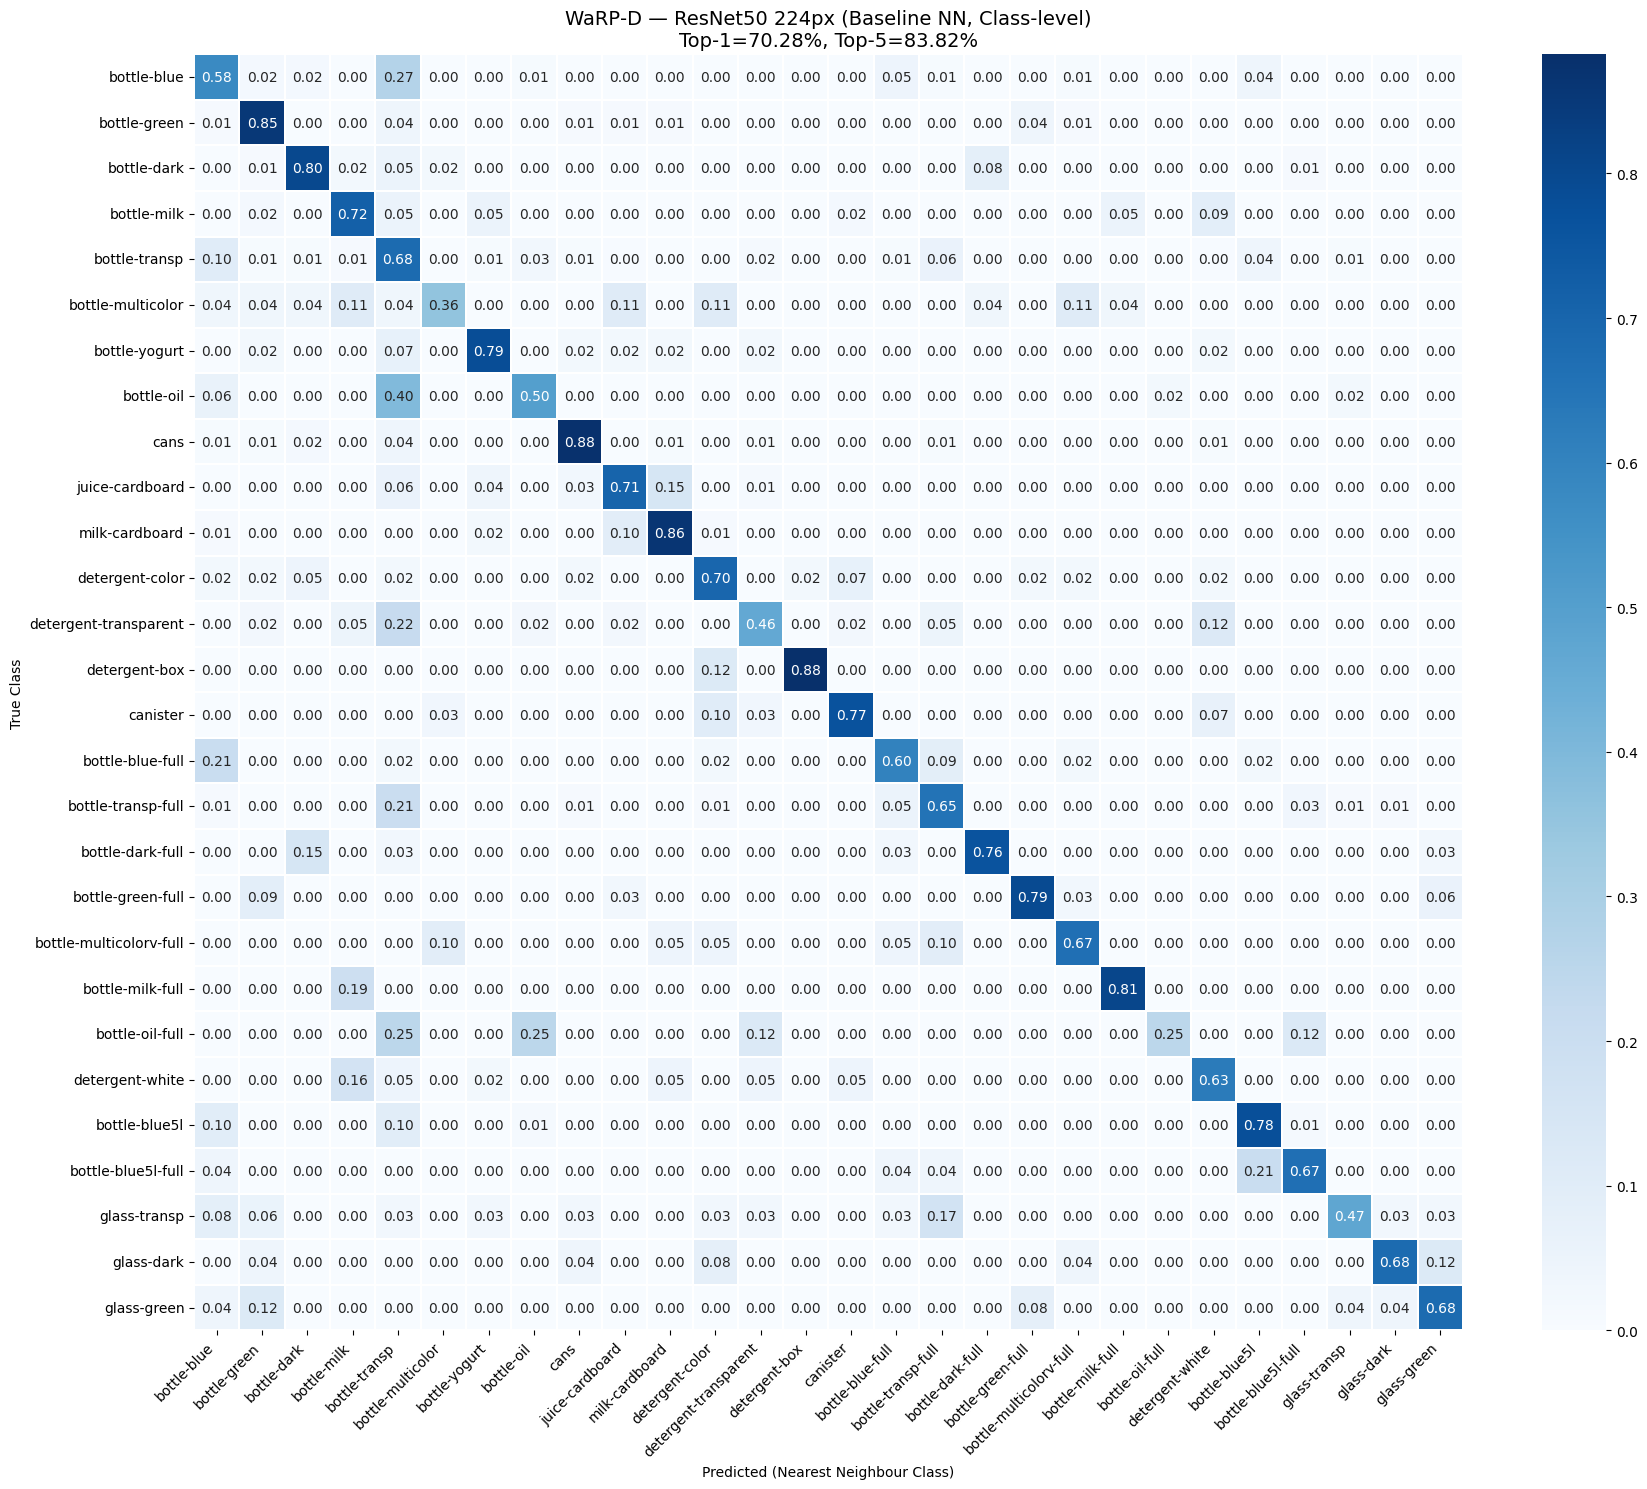

In [22]:
y_true = query_labels
y_pred = np.array(nn_preds)

cm = confusion_matrix(y_true, y_pred, labels=range(len(CLASS_NAMES)))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(
    cm_norm,
    annot=True,              # ← add numbers
    fmt=".2f",               # ← format numbers
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.3
)
ax.set_title(
    f"WaRP‑D — ResNet50 224px (Baseline NN, Class‑level)\nTop‑1={top1_acc:.2f}%, Top‑5={top5_acc:.2f}%",
    fontsize=14
)
ax.set_xlabel("Predicted (Nearest Neighbour Class)")
ax.set_ylabel("True Class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# 10 — Optional projection head on logits

In [17]:
class LogitProjectionHead(nn.Module):
    def __init__(self, in_dim, embed_dim, num_classes):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(in_dim, embed_dim),
            nn.ReLU(inplace=True),
        )
        self.cls = nn.Linear(embed_dim, num_classes)

    def forward(self, logits):
        z = self.proj(logits)
        out = self.cls(z)
        return z, out

# Freeze base classifier
for p in model.parameters():
    p.requires_grad = False

proj_head = LogitProjectionHead(
    in_dim     = NUM_CLASSES,
    embed_dim  = EMBED_DIM,
    num_classes= NUM_CLASSES,
).to(DEVICE)

opt_proj = torch.optim.AdamW(proj_head.parameters(), lr=1e-3, weight_decay=1e-4)
ce_loss  = nn.CrossEntropyLoss()

EPOCHS_PROJ = 10
print("Training projection head for", EPOCHS_PROJ, "epochs on WaRP‑D crops...")


Training projection head for 10 epochs on WaRP‑D crops...


# 11 — Train projection head (optional)

In [18]:
proj_head.train()
for epoch in range(1, EPOCHS_PROJ + 1):
    t0 = time.time()
    ep_loss = correct = total = 0

    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)

        with torch.no_grad():
            logits = model(imgs)  # [B, NUM_CLASSES]

        z, out = proj_head(logits)
        loss   = ce_loss(out, lbls)

        opt_proj.zero_grad()
        loss.backward()
        opt_proj.step()

        ep_loss += loss.item()
        correct += (out.argmax(1) == lbls).sum().item()
        total   += lbls.size(0)

    train_loss = ep_loss / len(train_loader)
    train_acc  = correct / total * 100
    print(f"Epoch {epoch:2d}/{EPOCHS_PROJ} | loss={train_loss:.4f} | acc={train_acc:.2f}% | {time.time()-t0:.1f}s")

proj_head.eval()


Epoch  1/10 | loss=0.6273 | acc=82.84% | 42.6s
Epoch  2/10 | loss=0.2457 | acc=92.02% | 43.1s
Epoch  3/10 | loss=0.2254 | acc=92.46% | 43.3s
Epoch  4/10 | loss=0.2140 | acc=92.80% | 43.9s
Epoch  5/10 | loss=0.2055 | acc=93.10% | 43.9s
Epoch  6/10 | loss=0.1989 | acc=93.26% | 43.7s
Epoch  7/10 | loss=0.1931 | acc=93.40% | 43.8s
Epoch  8/10 | loss=0.1883 | acc=93.49% | 43.9s
Epoch  9/10 | loss=0.1838 | acc=93.64% | 43.9s
Epoch 10/10 | loss=0.1796 | acc=93.77% | 45.4s


LogitProjectionHead(
  (proj): Sequential(
    (0): Linear(in_features=28, out_features=128, bias=True)
    (1): ReLU(inplace=True)
  )
  (cls): Linear(in_features=128, out_features=28, bias=True)
)

# 12 — Embeddings with projection head

In [19]:
def build_proj_embedding_bank(loader, base_model, head, device=DEVICE):
    base_model.eval()
    head.eval()
    all_embs, all_labels = [], []

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            logits = base_model(imgs)
            z, _  = head(logits)
            embs  = z.detach().cpu().numpy()
            all_embs.append(embs)
            all_labels.append(lbls.numpy())

    all_embs   = np.concatenate(all_embs, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    return all_embs, all_labels

print("Building gallery (train) embeddings [projection head]...")
gallery_embs_p, gallery_labels_p = build_proj_embedding_bank(train_loader, model, proj_head)
print("Gallery (proj) shape:", gallery_embs_p.shape)

print("Building query (test) embeddings [projection head]...")
query_embs_p, query_labels_p = build_proj_embedding_bank(test_loader, model, proj_head)
print("Query (proj) shape  :", query_embs_p.shape)


Building gallery (train) embeddings [projection head]...
Gallery (proj) shape: (8823, 128)
Building query (test) embeddings [projection head]...
Query (proj) shape  : (1551, 128)


# 13 — Retrieval with projection‑head embeddings

In [20]:
print("Computing cosine similarity (projection head)...")
sim_matrix_p = cosine_similarity(query_embs_p, gallery_embs_p)

top1_correct_p = 0
top5_correct_p = 0
nn_preds_p = []

for i in range(sim_matrix_p.shape[0]):
    sims = sim_matrix_p[i]
    idxs = np.argsort(-sims)
    top1 = gallery_labels_p[idxs[0]]
    top5 = gallery_labels_p[idxs[:TOP_K]]

    nn_preds_p.append(top1)

    if top1 == query_labels_p[i]:
        top1_correct_p += 1
    if query_labels_p[i] in top5:
        top5_correct_p += 1

top1_acc_p = top1_correct_p / len(query_labels_p) * 100
top5_acc_p = top5_correct_p / len(query_labels_p) * 100

print("="*50)
print("WaRP‑D — ResNet50 224px (Projection‑Head Embeddings, Class‑level)")
print("="*50)
print(f"Top‑1 Class‑level ID Accuracy : {top1_acc_p:.2f}%")
print(f"Top‑5 Class‑level ID Accuracy : {top5_acc_p:.2f}%")
print("="*50)


Computing cosine similarity (projection head)...
WaRP‑D — ResNet50 224px (Projection‑Head Embeddings, Class‑level)
Top‑1 Class‑level ID Accuracy : 71.82%
Top‑5 Class‑level ID Accuracy : 83.75%


# 14 — Confusion matrix (projection‑head embeddings)

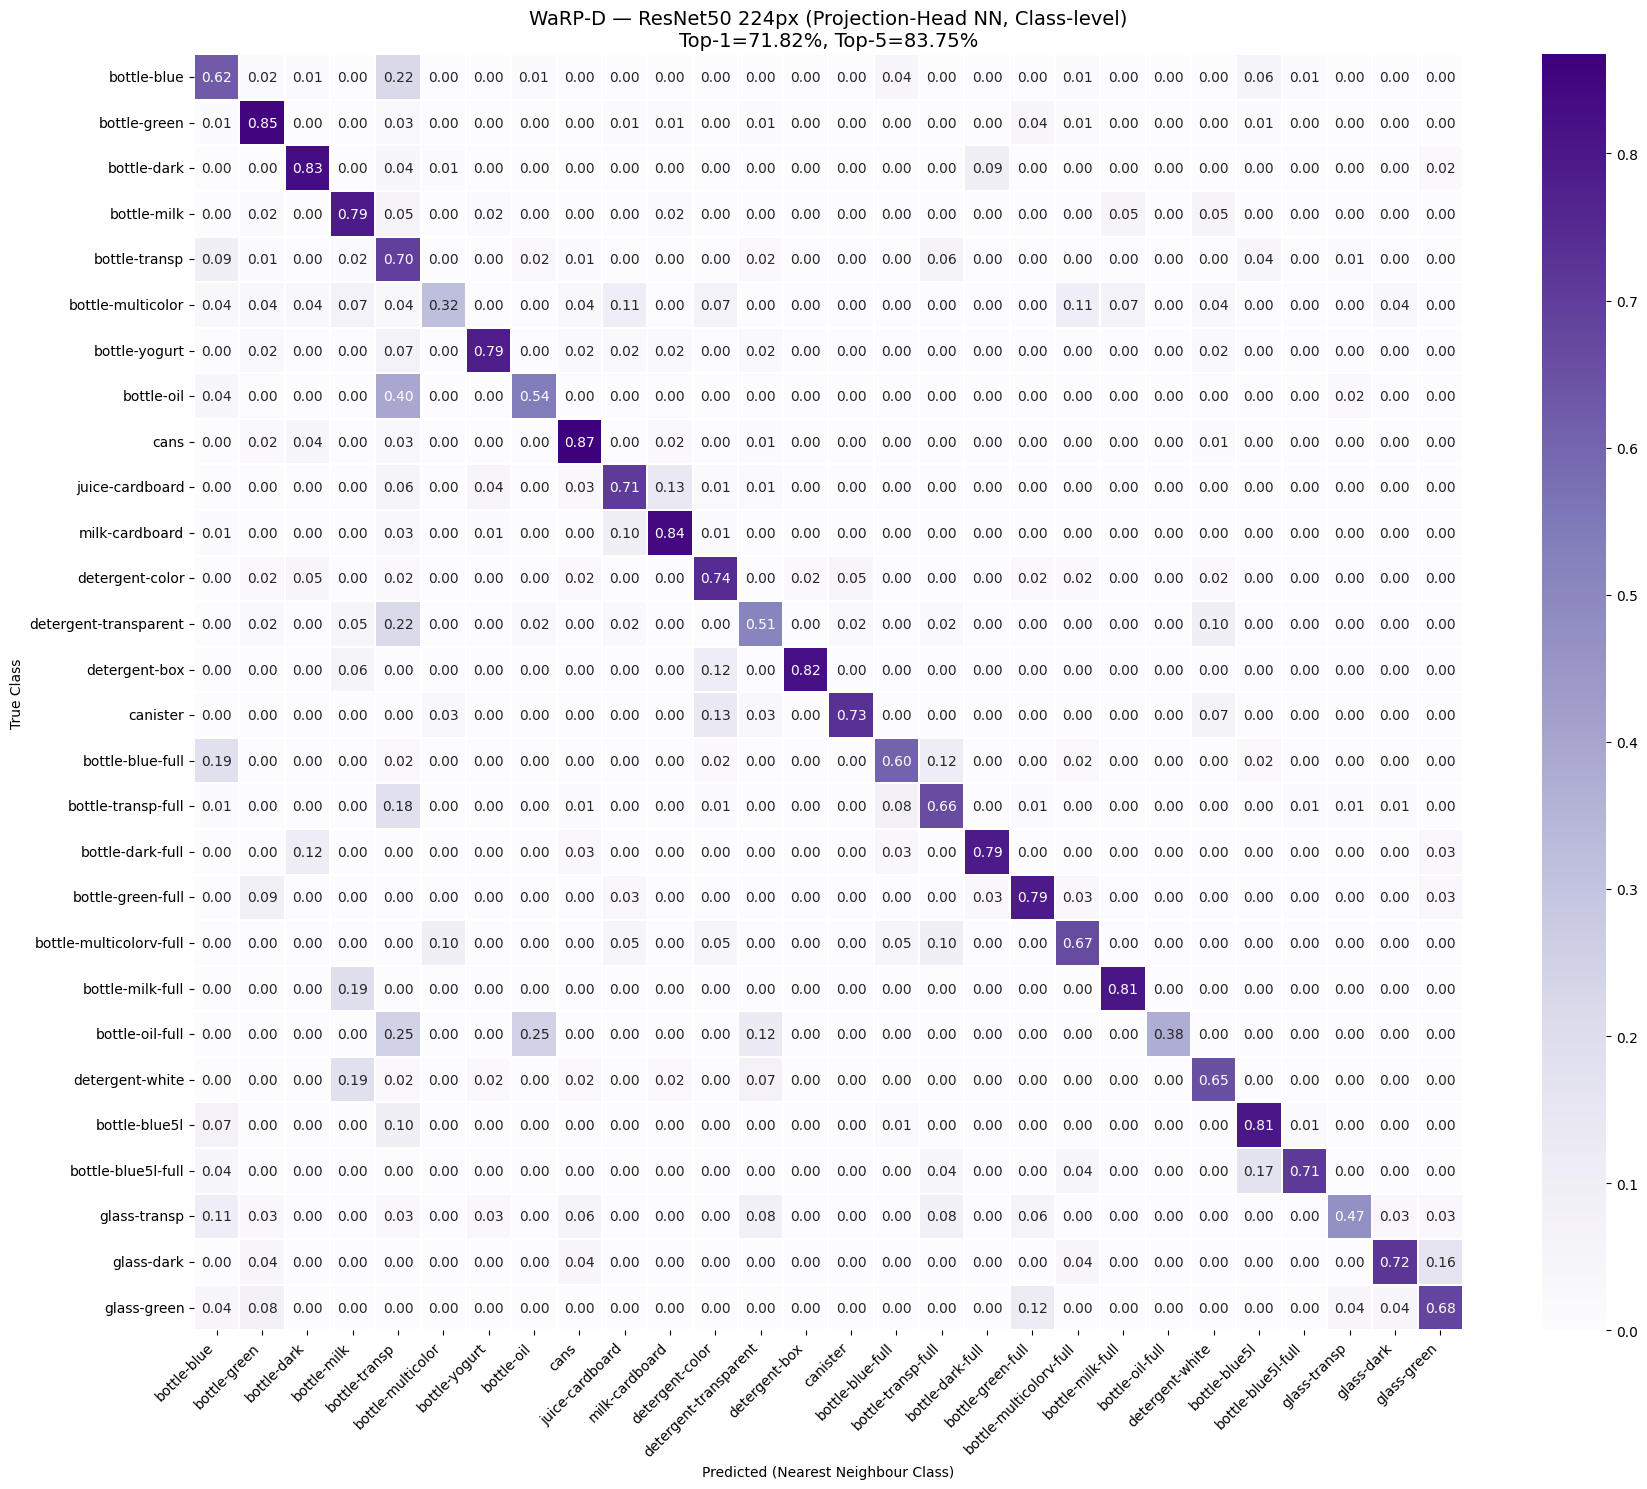

In [23]:
y_true_p = query_labels_p
y_pred_p = np.array(nn_preds_p)

cm_p = confusion_matrix(y_true_p, y_pred_p, labels=range(len(CLASS_NAMES)))
cm_norm_p = cm_p.astype(float) / cm_p.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(
    cm_norm_p,
    annot=True,              # ← add numbers
    fmt=".2f",               # ← format numbers
    cmap="Purples",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.3
)
ax.set_title(
    f"WaRP‑D — ResNet50 224px (Projection‑Head NN, Class‑level)\nTop‑1={top1_acc_p:.2f}%, Top‑5={top5_acc_p:.2f}%",
    fontsize=14
)
ax.set_xlabel("Predicted (Nearest Neighbour Class)")
ax.set_ylabel("True Class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
